In [1]:
import os
import sys
import MDAnalysis as mda
import numpy as np
from sklearn.cluster import KMeans
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd
import nglview as nv
import gumpy
import copy
from collections import defaultdict
from pprint import pprint

path = os.path.join('..', '.')
if path not in sys.path:
    sys.path.append(os.path.abspath(path))

from src.protein_graph import pncaGraph

## Get coords of centre of masses of PncA residues

In [2]:
pnca = pncaGraph(
    pdb='../pdb/3PL1-PZA.pdb',
    lig_resname='PZA', 
    self_loops=False,
    cutoff_distance=12)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:348: UserWarning: Unknown element  found for some atoms. These have been given an empty element record. If needed they can be guessed using MDAnalysis.topology.guessers.
  warnings.warn(wmsg)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: 
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


In [3]:
res_coords = pnca.nodes.center_of_mass(compound='residues')

## K-means on residue coords

In [4]:
K = 18
region = KMeans(n_clusters=K, random_state=42, n_init="auto").fit_predict(res_coords)

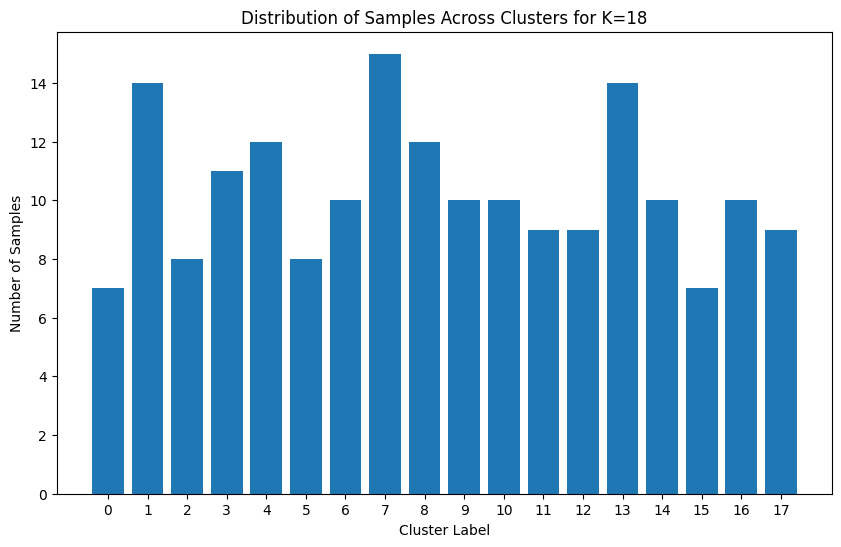

In [5]:
# plot distribution of samples across clusters

counts = np.unique(region, return_counts=True)

plt.figure(figsize=(10, 6))
plt.bar(counts[0], counts[1])
plt.xticks(counts[0])
plt.xlabel('Cluster Label')
plt.ylabel('Number of Samples')
plt.title(f'Distribution of Samples Across Clusters for K={K}')
plt.show()

## Assign mutations from dataset to respective clusters

In [6]:
pnca_paper_dataset = pd.read_csv('../data/ds-traintest-phen.csv')

def split_mutation(row):
    return pd.Series([row.MUTATION[0], int(row.MUTATION[1:-1]), row.MUTATION[-1]])

pnca_paper_dataset[['REF','AMINO_ACID','ALT']] = pnca_paper_dataset.apply(split_mutation,axis=1)

pnca_paper_dataset.head(10)

,MUTATION,CONSISTENT_PHENOTYPE,REF,AMINO_ACID,ALT
0,A102V,S,A,102,V
1,A134D,S,A,134,D
2,A134P,R,A,134,P
3,A134S,S,A,134,S
4,A134V,R,A,134,V
5,A143D,R,A,143,D
6,A143G,R,A,143,G
7,A143V,S,A,143,V
8,A146E,R,A,146,E
9,A146S,R,A,146,S


In [7]:
res_to_region = {pos: int(region[pos-1]) for pos in range(1, res_coords.shape[0]+1)}

pnca_paper_dataset['cluster'] = pnca_paper_dataset['AMINO_ACID'].map(res_to_region)

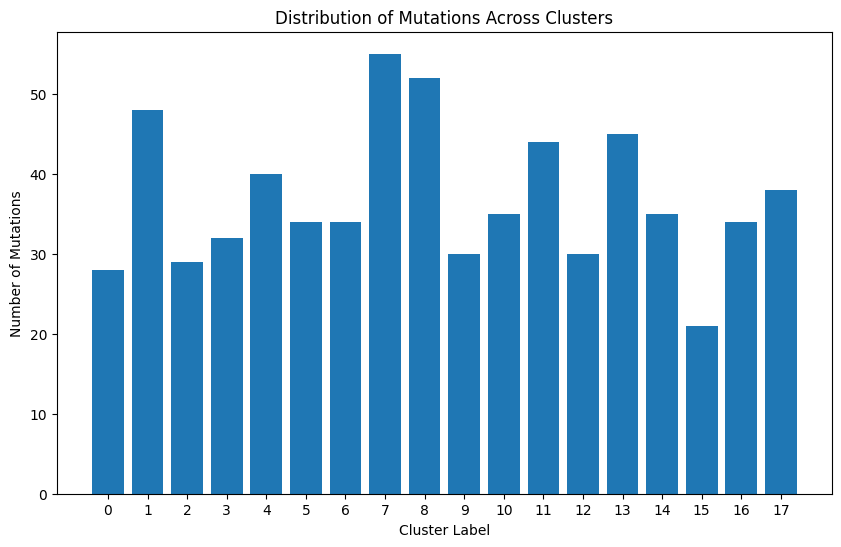

In [8]:
cluster_counts = pnca_paper_dataset['cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel('Cluster Label')
plt.ylabel('Number of Mutations')
plt.title('Distribution of Mutations Across Clusters')
plt.xticks(range(K))
plt.show()

## Inspect clusters

In [9]:
# dict with clusters as keys and residues as values 
region_to_res = {}
for res, region in res_to_region.items():
    region_to_res.setdefault(region, []).append(res)

In [10]:
colormap = matplotlib.colormaps['tab20']
col_dict = {i: matplotlib.colors.rgb2hex(colormap(i)) for i in range(K)}

col_dict


{0: '#1f77b4',
 1: '#aec7e8',
 2: '#ff7f0e',
 3: '#ffbb78',
 4: '#2ca02c',
 5: '#98df8a',
 6: '#d62728',
 7: '#ff9896',
 8: '#9467bd',
 9: '#c5b0d5',
 10: '#8c564b',
 11: '#c49c94',
 12: '#e377c2',
 13: '#f7b6d2',
 14: '#7f7f7f',
 15: '#c7c7c7',
 16: '#bcbd22',
 17: '#dbdb8d'}

In [11]:
rep = [{"type": "spacefill", "params": {
    "sele": f"({', '.join(map(str, region_to_res[cluster]))}) and .CA",
    "color" : col_dict[cluster]}}
       for cluster in range(K)]

rep.append({"type": "licorice", "params": {
    "sele": "not protein",
    # "color" : "black"
    }})

In [12]:
view = nv.show_file("../pdb/3PL1-PZA.pdb")

view.set_representations(rep)

view

NGLWidget()

Get selection foo for VMD

In [26]:
for i in region_to_res:
    residues = ''.join([str(res) + ' ' for res in region_to_res[i]])
    print(f"backbone resid {residues}")

backbone resid 1 2 3 42 117 120 121 124 125 126 127 128 151 152 
backbone resid 4 6 41 43 44 45 46 87 88 89 90 91 
backbone resid 5 7 8 47 105 130 138 139 142 
backbone resid 9 27 30 31 131 132 158 159 160 
backbone resid 10 11 12 13 17 48 72 77 78 79 80 81 
backbone resid 14 15 16 20 21 22 23 24 133 161 
backbone resid 18 19 58 60 69 70 71 
backbone resid 25 26 28 29 82 83 84 85 
backbone resid 32 33 34 35 36 37 38 39 40 86 
backbone resid 49 96 97 102 103 104 107 108 
backbone resid 50 52 73 74 75 76 95 
backbone resid 51 53 54 55 56 57 98 99 100 101 
backbone resid 59 61 62 63 64 65 66 67 68 
backbone resid 92 93 94 109 110 111 112 113 114 115 116 118 119 122 123 
backbone resid 106 141 143 144 145 146 147 148 149 150 153 178 179 180 
backbone resid 129 154 155 156 157 181 182 183 184 185 
backbone resid 134 135 136 137 162 163 164 165 166 167 168 
backbone resid 140 169 170 171 172 173 174 175 176 177 


## Assign clusters to train/test

In [13]:
# try and balance class labels (R and S) in both train and test sets? [too strong a constraint/inductive bias]
# also try and achieve close to our desired split fraction (70:30)

def global_targets(df, label_col, test_frac):
    total_n = len(df)
    label_dist = df[label_col].value_counts(normalize=True).to_dict()
    return {
        "n_test": total_n * test_frac,
        "label_frac": label_dist
    }

targets = global_targets(pnca_paper_dataset, 'CONSISTENT_PHENOTYPE', test_frac=0.3)

# get the number of Rs and Ss per cluster

def get_cluster_label_stats(df, cluster_col, label_col):
    cluster_label_stats = {}
    for cid, g in df.groupby(cluster_col):
        cluster_label_stats[cid] = {
            "n": len(g),
            "label_counts": g[label_col].value_counts().to_dict()
        }
    return cluster_label_stats

cluster_label_stats = get_cluster_label_stats(pnca_paper_dataset, 'cluster', 'CONSISTENT_PHENOTYPE')
    
pprint(cluster_label_stats)
print('\n')
pprint(targets)

{0: {'label_counts': {'R': 18, 'S': 10}, 'n': 28},
 1: {'label_counts': {'R': 19, 'S': 29}, 'n': 48},
 2: {'label_counts': {'R': 8, 'S': 21}, 'n': 29},
 3: {'label_counts': {'R': 20, 'S': 12}, 'n': 32},
 4: {'label_counts': {'R': 19, 'S': 21}, 'n': 40},
 5: {'label_counts': {'R': 28, 'S': 6}, 'n': 34},
 6: {'label_counts': {'R': 15, 'S': 19}, 'n': 34},
 7: {'label_counts': {'R': 25, 'S': 30}, 'n': 55},
 8: {'label_counts': {'R': 31, 'S': 21}, 'n': 52},
 9: {'label_counts': {'R': 12, 'S': 18}, 'n': 30},
 10: {'label_counts': {'R': 9, 'S': 26}, 'n': 35},
 11: {'label_counts': {'R': 39, 'S': 5}, 'n': 44},
 12: {'label_counts': {'R': 19, 'S': 11}, 'n': 30},
 13: {'label_counts': {'R': 18, 'S': 27}, 'n': 45},
 14: {'label_counts': {'R': 16, 'S': 19}, 'n': 35},
 15: {'label_counts': {'R': 5, 'S': 16}, 'n': 21},
 16: {'label_counts': {'R': 21, 'S': 13}, 'n': 34},
 17: {'label_counts': {'R': 27, 'S': 11}, 'n': 38}}


{'label_frac': {'R': 0.5256024096385542, 'S': 0.4743975903614458},
 'n_test':

In [14]:
def split_clusters_balanced_from_stats(
    cluster_ids,
    cluster_stats,
    targets,
    alpha=1.0, # controls split balance
    beta=5.0, # controls label balance
    seed=0
):
    """
    cluster_ids:   array of cluster ids per residue
    cluster_stats: dict[cid] -> {"n": int, "label_counts": dict}
    targets:       {"n_test": float, "label_frac": dict}
    returns:       boolean mask, True = test
    """
    rng = np.random.default_rng(seed)

    cluster_ids = np.asarray(cluster_ids)
    clusters = np.array(list(cluster_stats.keys()))
    rng.shuffle(clusters)

    remaining = set(clusters)
    test_clusters = set()

    cur_n = 0
    cur_label_cnt = defaultdict(int)

    def score_add(cid):
        new_n = cur_n + cluster_stats[cid]["n"]
        size_err = abs(new_n - targets["n_test"]) / targets["n_test"]

        label_err = 0.0
        for lbl, frac in targets["label_frac"].items():
            new_cnt = cur_label_cnt[lbl] + cluster_stats[cid]["label_counts"].get(lbl, 0)
            new_frac = new_cnt / max(new_n, 1)
            label_err += abs(new_frac - frac)

        return alpha * size_err + beta * label_err

    while cur_n < targets["n_test"] and remaining:
        best = min(remaining, key=score_add)
        remaining.remove(best)

        test_clusters.add(best)
        cur_n += cluster_stats[best]["n"]
        for lbl, cnt in cluster_stats[best]["label_counts"].items():
            cur_label_cnt[lbl] += cnt

    return np.array([cid in test_clusters for cid in cluster_ids])


In [15]:
def split_clusters_greedy(cluster_ids, test_frac=0.3, seed=42):
    """
    cluster_ids: array of cluster id per sample
    returns: boolean mask for test set (ie. test=True/train=False)
    """
    rng = np.random.default_rng(seed)

    # count samples per cluster
    unique, counts = np.unique(cluster_ids, return_counts=True)
    clusters = list(zip(unique, counts))

    rng.shuffle(clusters)

    total = counts.sum()
    target = total * test_frac

    test_clusters = set()
    running = 0

    for cid, size in clusters:
        if running >= target:
            break
        test_clusters.add(cid)
        running += size

    return np.array([cid in test_clusters for cid in cluster_ids])

In [16]:
test_mask = split_clusters_greedy(pnca_paper_dataset.cluster.values)
train_df = pnca_paper_dataset[~test_mask]
test_df = pnca_paper_dataset[test_mask]

test_df

,MUTATION,CONSISTENT_PHENOTYPE,REF,AMINO_ACID,ALT,cluster
14,A161E,S,A,161,E,6
15,A161P,R,A,161,P,6
16,A161S,S,A,161,S,6
17,A161T,S,A,161,T,6
26,A20E,S,A,20,E,6
...,...,...,...,...,...,...
656,Y64N,S,Y,64,N,12
660,Y99C,S,Y,99,C,16
661,Y99D,S,Y,99,D,16
662,Y99F,S,Y,99,F,16


In [17]:
# test_mask = split_clusters_balanced_from_stats(
#     cluster_ids = pnca_paper_dataset.cluster.values,
#     cluster_stats = cluster_label_stats,
#     targets = targets
#     )
# train_df = pnca_paper_dataset[~test_mask]
# test_df = pnca_paper_dataset[test_mask]

# test_df

In [18]:
print('Train clusters and counts:')
print(train_df.cluster.value_counts().sort_values())
print('\nTest clusters and counts:')
print(test_df.cluster.value_counts().sort_values())

print("Train size:", len(train_df))
print("Test size :", len(test_df))
print("\nTrain label distribution:")
print(train_df['CONSISTENT_PHENOTYPE'].value_counts(normalize=True))
print("\nTest label distribution:")
print(test_df['CONSISTENT_PHENOTYPE'].value_counts(normalize=True))

Train clusters and counts:
cluster
15    21
0     28
2     29
3     32
5     34
14    35
4     40
11    44
13    45
1     48
8     52
7     55
Name: count, dtype: int64

Test clusters and counts:
cluster
9     30
12    30
6     34
16    34
10    35
17    38
Name: count, dtype: int64
Train size: 463
Test size : 201

Train label distribution:
CONSISTENT_PHENOTYPE
R    0.531317
S    0.468683
Name: proportion, dtype: float64

Test label distribution:
CONSISTENT_PHENOTYPE
R    0.512438
S    0.487562
Name: proportion, dtype: float64


## Vis train/test clusters

In [19]:
train_col = 'red'
test_col = 'cyan'

rep = [{"type": "spacefill", "params": {
    "sele": f"({', '.join(map(str, region_to_res[cluster]))}) and .CA",
    "color" : train_col if cluster in train_df.cluster.values else test_col}}
       for cluster in range(K)]

rep.append({"type": "licorice", "params": {
    "sele": "not protein",
    # "color" : "black"
    }})

In [20]:
view = nv.show_file("../pdb/3PL1-PZA.pdb")

view.set_representations(rep)

view

NGLWidget()

### Create train / test split based on clusters

In [115]:
reference = gumpy.Genome('../data/NC_000962.3.gbk')
pnca = reference.build_gene('pncA')

In [116]:
# create table of sample sequences

sequences = pd.DataFrame(columns=['phenotype_label','number_resistant_mutations', 'number_susceptible_mutations', 'allele', 'MUTATION'])

for idx, row in pnca_paper_dataset.iterrows():
    
    sample = copy.deepcopy(pnca)
    # reassign amino acid to mutated amino acid
    sample.amino_acid_sequence[sample.amino_acid_number==row.AMINO_ACID] = row.ALT
    
    sequence = ''.join(i for i in sample.amino_acid_sequence)
    mutation = row.MUTATION
    
    if row.CONSISTENT_PHENOTYPE == 'R':
        number_resistant_mutations = 1
        number_susceptible_mutations = 0
        phenotype_label = 'R'
    else:
        number_resistant_mutations = 0
        number_susceptible_mutations = 1
        phenotype_label = 'S'
        
    sequences.loc[len(sequences)] = [phenotype_label, number_resistant_mutations, number_susceptible_mutations, sequence, mutation]
    

In [117]:
train_seqs = pd.merge(sequences, train_df, on='MUTATION', how='inner')
test_seqs = pd.merge(sequences, test_df, on='MUTATION', how='inner')   

display(train_seqs)
display(test_seqs)

,phenotype_label,number_resistant_mutations,number_susceptible_mutations,allele,MUTATION,CONSISTENT_PHENOTYPE,REF,AMINO_ACID,ALT,cluster
0,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A102V,S,A,102,V,5
1,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A134D,S,A,134,D,3
2,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A134P,R,A,134,P,3
3,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A134S,S,A,134,S,3
4,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A134V,R,A,134,V,3
...,...,...,...,...,...,...,...,...,...,...
458,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,Y103S,R,Y,103,S,5
459,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADHHHVVA...,Y41H,R,Y,41,H,4
460,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,Y95C,S,Y,95,C,15
461,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,Y95H,S,Y,95,H,15


,phenotype_label,number_resistant_mutations,number_susceptible_mutations,allele,MUTATION,CONSISTENT_PHENOTYPE,REF,AMINO_ACID,ALT,cluster
0,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A161E,S,A,161,E,6
1,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A161P,R,A,161,P,6
2,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A161S,S,A,161,S,6
3,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A161T,S,A,161,T,6
4,S,0,1,MRALIIVDVQNDFCEGGSLEVTGGAALARAISDYLAEAADYHHVVA...,A20E,S,A,20,E,6
...,...,...,...,...,...,...,...,...,...,...
196,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,Y64N,S,Y,64,N,12
197,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,Y99C,S,Y,99,C,16
198,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,Y99D,S,Y,99,D,16
199,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,Y99F,S,Y,99,F,16


In [118]:
with open('../data/clustered_train_sequences_2.csv', 'wb') as file:
    train_seqs.to_csv(file, index=False)

with open('../data/clustered_test_sequences_2.csv', 'wb') as file:
    test_seqs.to_csv(file, index=False)

## Create train / test split based on codon position

In [119]:
test_mask = split_clusters_greedy(pnca_paper_dataset.AMINO_ACID.values, seed=0)
train_df = pnca_paper_dataset[~test_mask]
test_df = pnca_paper_dataset[test_mask]

test_df

,MUTATION,CONSISTENT_PHENOTYPE,REF,AMINO_ACID,ALT,cluster
5,A143D,R,A,143,D,13
6,A143G,R,A,143,G,13
7,A143V,S,A,143,V,13
8,A146E,R,A,146,E,13
9,A146S,R,A,146,S,13
...,...,...,...,...,...,...
659,Y95N,S,Y,95,N,15
660,Y99C,S,Y,99,C,16
661,Y99D,S,Y,99,D,16
662,Y99F,S,Y,99,F,16


In [120]:
# # balanced label split by codon

# codon_label_stats = get_cluster_label_stats(pnca_paper_dataset, 'AMINO_ACID', 'CONSISTENT_PHENOTYPE')

# test_mask = split_clusters_balanced_from_stats(
#     cluster_ids=pnca_paper_dataset.AMINO_ACID.values,
#     cluster_stats=codon_label_stats,
#     targets=targets)

# train_df = pnca_paper_dataset[~test_mask]
# test_df = pnca_paper_dataset[test_mask]

# test_df

In [121]:
print("Train size:", len(train_df))
print("Test size :", len(test_df))
print("\nTrain label distribution:")
print(train_df['CONSISTENT_PHENOTYPE'].value_counts(normalize=True))
print("\nTest label distribution:")
print(test_df['CONSISTENT_PHENOTYPE'].value_counts(normalize=True))

Train size: 462
Test size : 202

Train label distribution:
CONSISTENT_PHENOTYPE
R    0.508658
S    0.491342
Name: proportion, dtype: float64

Test label distribution:
CONSISTENT_PHENOTYPE
R    0.564356
S    0.435644
Name: proportion, dtype: float64


## Vis train / test split by codon

In [122]:
train_col = 'red'
test_col = 'cyan'

rep = [{"type": "spacefill", "params": {
    "sele": f"({', '.join(map(str, set(df.AMINO_ACID.values)))}) and .CA",
    "color" : col}}
       for df, col in zip([train_df, test_df], [train_col, test_col])]

rep.append({"type": "licorice", "params": {
    "sele": "not protein",
    # "color" : "black"
    }})

In [123]:
view = nv.show_file("../pdb/3PL1-PZA.pdb")

view.set_representations(rep)

view

NGLWidget()

In [124]:
train_seqs = pd.merge(sequences, train_df, on='MUTATION', how='inner')
test_seqs = pd.merge(sequences, test_df, on='MUTATION', how='inner')   

display(train_seqs)
display(test_seqs)

,phenotype_label,number_resistant_mutations,number_susceptible_mutations,allele,MUTATION,CONSISTENT_PHENOTYPE,REF,AMINO_ACID,ALT,cluster
0,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A102V,S,A,102,V,5
1,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A134D,S,A,134,D,3
2,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A134P,R,A,134,P,3
3,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A134S,S,A,134,S,3
4,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A134V,R,A,134,V,3
...,...,...,...,...,...,...,...,...,...,...
457,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDCLAEAADYHHVVA...,Y34C,S,Y,34,C,10
458,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDDLAEAADYHHVVA...,Y34D,R,Y,34,D,10
459,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDHLAEAADYHHVVA...,Y34H,S,Y,34,H,10
460,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADHHHVVA...,Y41H,R,Y,41,H,4


,phenotype_label,number_resistant_mutations,number_susceptible_mutations,allele,MUTATION,CONSISTENT_PHENOTYPE,REF,AMINO_ACID,ALT,cluster
0,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A143D,R,A,143,D,13
1,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A143G,R,A,143,G,13
2,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A143V,S,A,143,V,13
3,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A146E,R,A,146,E,13
4,R,1,0,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,A146S,R,A,146,S,13
...,...,...,...,...,...,...,...,...,...,...
197,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,Y95N,S,Y,95,N,15
198,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,Y99C,S,Y,99,C,16
199,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,Y99D,S,Y,99,D,16
200,S,0,1,MRALIIVDVQNDFCEGGSLAVTGGAALARAISDYLAEAADYHHVVA...,Y99F,S,Y,99,F,16


In [ ]:
# with open('../data/balanced_codon_train_sequences.csv', 'wb') as file:
with open('../data/codon_train_sequences.csv', 'wb') as file:
    train_seqs.to_csv(file, index=False)

# with open('../data/balanced_codon_test_sequences.csv', 'wb') as file:
with open('../data/codon_test_sequences.csv', 'wb') as file:
    test_seqs.to_csv(file, index=False)